# Introduction to Data Analysis in Python

First we need to load two essential packages in Python that form the foundation of data analysis: NumPy for numerical computing and Pandas for working with structured (table-like) data.

In [2]:
"""
Python packages are usually imported at the beginning of scripts/jupyter notebooks
"""
import numpy as np
import pandas as pd

## Basic data structures in pandas
Pandas provides two types of classes for handling data:

**Series**: a one-dimensional labeled array holding data of any type
such as integers, strings, Python objects etc.

**DataFrame**: a two-dimensional data structure that holds data like a two-dimension array or a table with rows and columns.

## Object creation

### Series

In [6]:
s = pd.Series([1, 3, 5, 7, 6, 8])
s

0    1
1    3
2    5
3    7
4    6
5    8
dtype: int64

In [3]:
type(s)

pandas.core.series.Series

### DataFrames

We will focus on DataFrames from now on as they are more useful than Series

In [9]:
d = {"one": [1.0, 2.0, 3.0, 4.0], "two": [4.0, 3.0, 2.0, 1.0]}
pd.DataFrame(d)

,one,two
0,1.0,4.0
1,2.0,3.0
2,3.0,2.0
3,4.0,1.0


In [10]:
# You can also specify row names (index)
df = pd.DataFrame(d, index=["a", "b", "c", "d"])
df

,one,two
a,1.0,4.0
b,2.0,3.0
c,3.0,2.0
d,4.0,1.0


The row and column labels can be accessed respectively by accessing the index and columns attributes:

In [11]:
df.index

Index(['a', 'b', 'c', 'd'], dtype='object')

In [12]:
df.columns

Index(['one', 'two'], dtype='object')

## Column selection, addition, deletion

In [14]:
# Access a specific column
df["one"]

a    1.0
b    2.0
c    3.0
d    4.0
Name: one, dtype: float64

In [15]:
# Add columns based on other columns
df["three"] = df["one"] * df["two"]
df["flag"] = df["one"] > 2
df

,one,two,three,flag
a,1.0,4.0,4.0,False
b,2.0,3.0,6.0,False
c,3.0,2.0,6.0,True
d,4.0,1.0,4.0,True


In [16]:
# Delete a column
del df["two"]
df

,one,three,flag
a,1.0,4.0,False
b,2.0,6.0,False
c,3.0,6.0,True
d,4.0,4.0,True


In [17]:
# When inserting a single value, it will naturally be propagated to fill the column
df["foo"] = "bar"
df

,one,three,flag,foo
a,1.0,4.0,False,bar
b,2.0,6.0,False,bar
c,3.0,6.0,True,bar
d,4.0,4.0,True,bar


## Indexing / selection

The basics of indexing are as follows:

| Operation | Syntax | Result |
|----------|--------|--------|
| Select column | `df[col]` | Series |
| Select row by label | `df.loc[label]` | Series |
| Select row by integer location | `df.iloc[loc]` | Series |
| Slice rows | `df[5:10]` | DataFrame |
| Select rows by boolean vector | `df[bool_vec]` | DataFrame |

In [25]:
df

,one,three,flag,foo
a,1.0,4.0,False,bar
b,2.0,6.0,False,bar
c,3.0,6.0,True,bar
d,4.0,4.0,True,bar


In [27]:
# Select second row by label
df.loc['b']

one        2.0
three      6.0
flag     False
foo        bar
Name: b, dtype: object

In [29]:
# Select second row by integer label
df.iloc[1]

one        2.0
three      6.0
flag     False
foo        bar
Name: b, dtype: object

In [31]:
# Select the last three rows
df[1:4]

,one,three,flag,foo
b,2.0,6.0,False,bar
c,3.0,6.0,True,bar
d,4.0,4.0,True,bar


In [32]:
# Select the rows in which flag == True
df[df['flag']]

,one,three,flag,foo
c,3.0,6.0,True,bar
d,4.0,4.0,True,bar


## Console display

A very large DataFrame will be truncated to display them in the console. You can also get a summary using info().

In [33]:
# Large DataFrame (more rows than display limit)
df_large = pd.DataFrame({
    "patient_id": range(1, 101),
    "age": np.random.randint(30, 90, 100),
    "score": np.random.normal(50, 10, 100)
})
df_large

,patient_id,age,score
0,1,68,65.674739
1,2,82,60.717772
2,3,46,54.592712
3,4,45,51.549656
4,5,60,51.360115
...,...,...,...
95,96,61,54.485825
96,97,73,47.913700
97,98,61,45.855308
98,99,60,64.157620


In [34]:
print(df_large)

    patient_id  age      score
0            1   68  65.674739
1            2   82  60.717772
2            3   46  54.592712
3            4   45  51.549656
4            5   60  51.360115
..         ...  ...        ...
95          96   61  54.485825
96          97   73  47.913700
97          98   61  45.855308
98          99   60  64.157620
99         100   76  65.070743

[100 rows x 3 columns]


In [35]:
df_large.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  100 non-null    int64  
 1   age         100 non-null    int32  
 2   score       100 non-null    float64
dtypes: float64(1), int32(1), int64(1)
memory usage: 2.1 KB


## Head and tail

To view a small sample of a Series or DataFrame object, use the head() and tail() methods. The default number of elements to display is five, but you may pass a custom number.

In [36]:
df_large.head()

,patient_id,age,score
0,1,68,65.674739
1,2,82,60.717772
2,3,46,54.592712
3,4,45,51.549656
4,5,60,51.360115


In [37]:
df_large.head(3)

,patient_id,age,score
0,1,68,65.674739
1,2,82,60.717772
2,3,46,54.592712


In [38]:
df_large.tail(4)

,patient_id,age,score
96,97,73,47.913700
97,98,61,45.855308
98,99,60,64.157620
99,100,76,65.070743


## Rename Columns

In [43]:
df_large.columns

Index(['patient_id', 'age', 'score'], dtype='object')

In [44]:
# Rename columns by capitalizing the original column names
df_large.columns = [col.capitalize() for col in df_large.columns]
df_large.head()

,Patient_id,Age,Score
0,1,68,65.674739
1,2,82,60.717772
2,3,46,54.592712
3,4,45,51.549656
4,5,60,51.360115


## Boolean reductions

A Boolean reduction takes a set of True/False values and reduces them to a single summary value, such as:
1. “Are any patients meeting this condition?”
2. “Do all patients meet this condition?”

In [45]:
df = pd.DataFrame({
    "Age": [45, 60, 37, 72],
    "Score": [88, 92, 79, 65]
})
df

,Age,Score
0,45,88
1,60,92
2,37,79
3,72,65


In [46]:
# Are any patients older than 50?
(df["Age"] > 50).any()

np.True_

In [47]:
# Are all patients older than 50?
(df["Age"] > 50).all()

np.False_

## Descriptive statistics

Some useful functions: mean(), sum(), min(), max(), median()

DataFrame: “index” (axis=0, default), “columns” (axis=1)

In [55]:
df = pd.DataFrame({
    "one":   [1, 2, 3, 4],
    "two":   [5, 6, 7, 8],
    "three": [9, 10, 11, 12]
}, index=["a", "b", "c", "d"])
df

,one,two,three
a,1,5,9
b,2,6,10
c,3,7,11
d,4,8,12


In [56]:
# Column-wise mean
df.mean(axis=0)

one       2.5
two       6.5
three    10.5
dtype: float64

In [57]:
# Row-wise mean
df.mean(axis=1)

a    5.0
b    6.0
c    7.0
d    8.0
dtype: float64

In [63]:
# max of all values
df.max(axis=None)

12

In [65]:
# Column-wise summary statistics
df.describe()

,one,two,three
count,4.000000,4.000000,4.000000
mean,2.500000,6.500000,10.500000
std,1.290994,1.290994,1.290994
min,1.000000,5.000000,9.000000
25%,1.750000,5.750000,9.750000
50%,2.500000,6.500000,10.500000
75%,3.250000,7.250000,11.250000
max,4.000000,8.000000,12.000000


## Categorical Data Summaries

While `.describe()` is excellent for continuous numerical data, clinical datasets are full of categorical variables (e.g., disease stage, blood type, readmission status). To quickly summarize these, we use `value_counts()`, which counts the number of times each unique value appears.

In [7]:
df_cat = pd.DataFrame({
    "patient_id": range(1, 11),
    "tumor_stage": ["Stage I", "Stage II", "Stage I", "Stage III", "Stage II", 
                    "Stage I", "Stage IV", "Stage II", "Stage I", "Stage II"]
})

# Get raw counts for each category
df_cat["tumor_stage"].value_counts()

tumor_stage
Stage I      4
Stage II     4
Stage III    1
Stage IV     1
Name: count, dtype: int64

In [8]:
# Get the relative frequencies (percentages) by setting normalize=True
df_cat["tumor_stage"].value_counts(normalize=True) * 100

tumor_stage
Stage I      40.0
Stage II     40.0
Stage III    10.0
Stage IV     10.0
Name: proportion, dtype: float64

## Finding Unique Values

* `unique()` returns an array of all distinct values.
* `nunique()` returns the *count* of distinct values.

In [9]:
df_visits = pd.DataFrame({
    "visit_id": [101, 102, 103, 104, 105],
    "patient_id": ["PT-001", "PT-001", "PT-002", "PT-003", "PT-002"],
    "adverse_event": ["Nausea", "None", "Headache", "None", "nausea"]
})

# How many unique patients are actually in this dataset?
num_patients = df_visits["patient_id"].nunique()
print(f"Total distinct patients: {num_patients}")

# What are the unique adverse events logged?
df_visits["adverse_event"].unique()

Total distinct patients: 3


array(['Nausea', 'None', 'Headache', 'nausea'], dtype=object)

## Working with Dates and Times

Pandas has a dedicated `datetime` data type that allows you to perform date math, like calculating a patient's length of stay.

We use `pd.to_datetime()` to convert standard text strings into pandas datetime objects.

In [10]:
df_dates = pd.DataFrame({
    "patient_id": [1, 2, 3],
    "admission_date": ["2023-01-10", "2023-02-15", "2023-03-01"],
    "discharge_date": ["2023-01-14", "2023-02-28", "2023-03-02"]
})

# Convert string columns to datetime objects
df_dates["admission_date"] = pd.to_datetime(df_dates["admission_date"])
df_dates["discharge_date"] = pd.to_datetime(df_dates["discharge_date"])

# Calculate length of stay (LOS)
df_dates["length_of_stay_days"] = df_dates["discharge_date"] - df_dates["admission_date"]
df_dates

,patient_id,admission_date,discharge_date,length_of_stay_days
0,1,2023-01-10,2023-01-14,4 days
1,2,2023-02-15,2023-02-28,13 days
2,3,2023-03-01,2023-03-02,1 days


## Basic String Manipulation

Pandas provides the `.str` accessor to apply string methods to an entire column at once.

In [11]:
df_strings = pd.DataFrame({
    "patient_id": [1, 2, 3, 4],
    "sex_entry": ["Male", "female ", " MALE", "Female"]
})

print("Before cleaning:")
print(df_strings["sex_entry"].value_counts())

# Clean the strings: make lowercase, then strip whitespace
df_strings["sex_clean"] = df_strings["sex_entry"].str.lower().str.strip()

print("\nAfter cleaning:")
print(df_strings["sex_clean"].value_counts())

Before cleaning:
sex_entry
Male       1
female     1
 MALE      1
Female     1
Name: count, dtype: int64

After cleaning:
sex_clean
male      2
female    2
Name: count, dtype: int64


## Sorting

Pandas supports three kinds of sorting: sorting by index labels, sorting by column values, and sorting by a combination of both. Ascending = True is the default.

In [66]:
df = pd.DataFrame({
    "Age": [45, 60, 37, 52],
    "Score": [88, 92, 79, 85]
}, index=["d", "b", "a", "c"])
df

,Age,Score
d,45,88
b,60,92
a,37,79
c,52,85


In [67]:
# Sort by index
df.sort_index()

,Age,Score
a,37,79
b,60,92
c,52,85
d,45,88


In [68]:
# Sort by Age
df.sort_values(by="Age")

,Age,Score
a,37,79
d,45,88
c,52,85
b,60,92


In [69]:
# Sort by Score (descending)
df.sort_values(by="Score", ascending=False)

,Age,Score
b,60,92
d,45,88
c,52,85
a,37,79


In [70]:
# Sorts by Age first and then sorts by Score if there is a tie
df2 = pd.DataFrame({
    "Age": [50, 50, 40],
    "Score": [90, 80, 85]
})

df2.sort_values(by=["Age", "Score"])

,Age,Score
2,40,85
1,50,80
0,50,90


## Grouping and Aggregation (groupby)

The `groupby()` method is one of the most powerful tools in pandas. It performs a "split-apply-combine" process:
1. **Split** the data into groups based on a categorical variable.
2. **Apply** a function (like mean, median, or count) to each group independently.
3. **Combine** the results into a new summary table.

In [4]:
# Let's create a sample dataset for grouping
df_group = pd.DataFrame({
    "patient_id": [1, 2, 3, 4, 5, 6],
    "treatment": ["Drug A", "Placebo", "Drug A", "Placebo", "Drug A", "Placebo"],
    "sex": ["M", "F", "F", "M", "M", "F"],
    "baseline_score": [55, 60, 52, 65, 58, 62],
    "followup_score": [85, 65, 88, 62, 90, 68]
})
df_group

,patient_id,treatment,sex,baseline_score,followup_score
0,1,Drug A,M,55,85
1,2,Placebo,F,60,65
2,3,Drug A,F,52,88
3,4,Placebo,M,65,62
4,5,Drug A,M,58,90
5,6,Placebo,F,62,68


In [5]:
# Calculate the mean follow-up score by treatment group
df_group.groupby("treatment")["followup_score"].mean()

treatment
Drug A     87.666667
Placebo    65.000000
Name: followup_score, dtype: float64

In [6]:
# You can also group by multiple columns and apply multiple aggregate functions
df_group.groupby(["treatment", "sex"])[["baseline_score", "followup_score"]].describe()

baseline_score                                                  \
                       count  mean       std   min    25%   50%    75%   max   
treatment sex                                                                  
Drug A    F              1.0  52.0       NaN  52.0  52.00  52.0  52.00  52.0   
          M              2.0  56.5  2.121320  55.0  55.75  56.5  57.25  58.0   
Placebo   F              2.0  61.0  1.414214  60.0  60.50  61.0  61.50  62.0   
          M              1.0  65.0       NaN  65.0  65.00  65.0  65.00  65.0   

              followup_score                                                  
                       count  mean       std   min    25%   50%    75%   max  
treatment sex                                                                 
Drug A    F              1.0  88.0       NaN  88.0  88.00  88.0  88.00  88.0  
          M              2.0  87.5  3.535534  85.0  86.25  87.5  88.75  90.0  
Placebo   F              2.0  66.5  2.121320  65.0  65.75  66.5  67.25  68.0  
          M              1.0  62.0       NaN  62.0  62.00  62.0  62.00  62.0

## IO tools (text, CSV, MS Excel, …)

The pandas I/O API is a set of top level reader functions accessed like `pd.read_csv()` that generally return a pandas object. The corresponding writer functions are object methods that are accessed like `DataFrame.to_csv()`. Below is a table containing available readers and writers.

| Format Type | Data Description | Reader       | Writer     |
|-------------|------------------|--------------|------------|
| text        | CSV              | `read_csv`   | `to_csv`   |
| binary      | MS Excel         | `read_excel` | `to_excel` |

In [84]:
"""
Reads in a csv file
pd.read_csv(..., sep = ) for any text files that are not comma-separated.
For example, pd.read_csv(..., sep = '\t') for tab-separated file
"""
df_csv = pd.read_csv("patients.csv")
df_csv

,patient_id,age,sex,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,treatment,outcome_score
0,1,45,Male,82,175,130,85,72,Yes,88
1,2,60,Female,70,162,145,90,78,No,75
2,3,37,Male,90,180,120,80,70,Yes,92
3,4,52,Female,65,158,135,88,76,No,80
4,5,29,Female,55,165,110,70,68,Yes,95
5,6,67,Male,88,172,150,92,82,No,70
6,7,41,Male,76,178,125,82,74,Yes,89
7,8,73,Female,68,160,155,95,85,No,65
8,9,50,Male,85,182,140,87,77,Yes,84
9,10,34,Female,60,168,118,75,69,Yes,93


In [85]:
# If you don't want to assume the first row of the file is the header
pd.read_csv("patients.csv", header=None)

,0,1,2,3,4,5,6,7,8,9
0,patient_id,age,sex,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,treatment,outcome_score
1,1,45,Male,82,175,130,85,72,Yes,88
2,2,60,Female,70,162,145,90,78,No,75
3,3,37,Male,90,180,120,80,70,Yes,92
4,4,52,Female,65,158,135,88,76,No,80
5,5,29,Female,55,165,110,70,68,Yes,95
6,6,67,Male,88,172,150,92,82,No,70
7,7,41,Male,76,178,125,82,74,Yes,89
8,8,73,Female,68,160,155,95,85,No,65
9,9,50,Male,85,182,140,87,77,Yes,84


In [75]:
# Write a DataFrame to a csv file
df = pd.DataFrame({
    "patient_id": [1, 2, 3],
    "age": [45, 60, 37],
    "treatment": ["Yes", "No", "Yes"]
})
df.to_csv("patients_output.csv", index=False)

In [94]:
# Read excel file (Sheet1)
df_excel = pd.read_excel("patients.xlsx", sheet_name='Sheet1')
df_excel

,patient_id,age,sex,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,treatment,outcome_score
0,1,45,Male,82,175,130,85,72,Yes,88
1,2,60,Female,70,162,145,90,78,No,75
2,3,37,Male,90,180,120,80,70,Yes,92
3,4,52,Female,65,158,135,88,76,No,80
4,5,29,Female,55,165,110,70,68,Yes,95
5,6,67,Male,88,172,150,92,82,No,70
6,7,41,Male,76,178,125,82,74,Yes,89
7,8,73,Female,68,160,155,95,85,No,65
8,9,50,Male,85,182,140,87,77,Yes,84
9,10,34,Female,60,168,118,75,69,Yes,93


In [96]:
# Read excel file (all sheets)
df_excel_all = pd.read_excel("patients.xlsx", sheet_name=None)
df_excel_all['Sheet1']

,patient_id,age,sex,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,treatment,outcome_score
0,1,45,Male,82,175,130,85,72,Yes,88
1,2,60,Female,70,162,145,90,78,No,75
2,3,37,Male,90,180,120,80,70,Yes,92
3,4,52,Female,65,158,135,88,76,No,80
4,5,29,Female,55,165,110,70,68,Yes,95
5,6,67,Male,88,172,150,92,82,No,70
6,7,41,Male,76,178,125,82,74,Yes,89
7,8,73,Female,68,160,155,95,85,No,65
8,9,50,Male,85,182,140,87,77,Yes,84
9,10,34,Female,60,168,118,75,69,Yes,93


In [98]:
df_excel_all['Sheet2']

,patient_id,follow_up_months,baseline_score,followup_score,adverse_event,readmission
0,1,6,85,88,No,No
1,2,6,78,75,Yes,Yes
2,3,12,90,92,No,No
3,4,6,82,80,No,No
4,5,12,88,95,No,No
5,6,3,72,70,Yes,Yes
6,7,6,86,89,No,No
7,8,3,70,65,Yes,Yes
8,9,12,80,84,No,No
9,10,6,89,93,No,No


## Merge, join, concatenate

In [103]:
# Concatenates along row axis (axis = 0) with pd.concat()
df1 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)

df2 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "C": ["C4", "C5", "C6", "C7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[4, 5, 6, 7],
)

df3 = pd.DataFrame(
    {
        "A": ["A8", "A9", "A10", "A11"],
        "B": ["B8", "B9", "B10", "B11"],
        "C": ["C8", "C9", "C10", "C11"],
        "D": ["D8", "D9", "D10", "D11"],
    },
    index=[8, 9, 10, 11],
)

frames = [df1, df2, df3]

result = pd.concat(frames)

result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


### Merging

In [106]:
patients = pd.DataFrame({
    "patient_id": [1, 2, 3, 4],
    "age": [45, 60, 37, 52],
    "sex": ["M", "F", "M", "F"]
})
labs = pd.DataFrame({
    "patient_id": [1, 2, 3, 5],
    "creatinine": [0.9, 1.2, 0.7, 1.0],
    "hemoglobin": [13.5, 12.1, 14.2, 11.8]
})

In [108]:
# Inner join (default): only patients in both datasets remain
df_merged = pd.merge(patients, labs, on="patient_id")
df_merged

,patient_id,age,sex,creatinine,hemoglobin
0,1,45,M,0.9,13.5
1,2,60,F,1.2,12.1
2,3,37,M,0.7,14.2


In [111]:
# Left join: keeps all patients in the patients dataset, adds missing values accordingly
pd.merge(patients, labs, on="patient_id", how="left")

,patient_id,age,sex,creatinine,hemoglobin
0,1,45,M,0.9,13.5
1,2,60,F,1.2,12.1
2,3,37,M,0.7,14.2
3,4,52,F,NaN,NaN


In [113]:
# Right join: keeps all patients in the labs dataset
pd.merge(patients, labs, on="patient_id", how="right")

,patient_id,age,sex,creatinine,hemoglobin
0,1,45.0,M,0.9,13.5
1,2,60.0,F,1.2,12.1
2,3,37.0,M,0.7,14.2
3,5,NaN,NaN,1.0,11.8


In [114]:
# Outer join: keeps everything from all datasets
pd.merge(patients, labs, on="patient_id", how="outer")

,patient_id,age,sex,creatinine,hemoglobin
0,1,45.0,M,0.9,13.5
1,2,60.0,F,1.2,12.1
2,3,37.0,M,0.7,14.2
3,4,52.0,F,NaN,NaN
4,5,NaN,NaN,1.0,11.8


## Working with Missing Values

In [115]:
df = pd.DataFrame({
    "patient_id": [1, 2, 3, 4, 5],
    "age": [45, 60, np.nan, 52, 37],
    "blood_pressure": [120, np.nan, 135, 140, np.nan],
    "outcome_score": [88, 75, 90, np.nan, 85]
})
df

,patient_id,age,blood_pressure,outcome_score
0,1,45.0,120.0,88.0
1,2,60.0,NaN,75.0
2,3,NaN,135.0,90.0
3,4,52.0,140.0,NaN
4,5,37.0,NaN,85.0


In [116]:
# Check if each entry is NaN
df.isna()

,patient_id,age,blood_pressure,outcome_score
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,False,True
4,False,False,True,False


In [118]:
# Count missing values per column
df.isna().sum()

patient_id        0
age               1
blood_pressure    2
outcome_score     1
dtype: int64

In [119]:
# Drop any row with at least one missing value
df.dropna()

,patient_id,age,blood_pressure,outcome_score
0,1,45.0,120.0,88.0


In [120]:
# Drop any column with at least one missing value
df.dropna(axis=1)

,patient_id
0,1
1,2
2,3
3,4
4,5


In [121]:
# Replace any NaN with 0
df.fillna(0)

,patient_id,age,blood_pressure,outcome_score
0,1,45.0,120.0,88.0
1,2,60.0,0.0,75.0
2,3,0.0,135.0,90.0
3,4,52.0,140.0,0.0
4,5,37.0,0.0,85.0


In [122]:
# Replace any NaN with column mean
df["age"] = df["age"].fillna(df["age"].mean())
df["blood_pressure"] = df["blood_pressure"].fillna(df["blood_pressure"].mean())
df["outcome_score"] = df["outcome_score"].fillna(df["outcome_score"].mean())
df

,patient_id,age,blood_pressure,outcome_score
0,1,45.0,120.000000,88.0
1,2,60.0,131.666667,75.0
2,3,48.5,135.000000,90.0
3,4,52.0,140.000000,84.5
4,5,37.0,131.666667,85.0


## Plotting with Seaborn and Matplotlib

In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df = pd.DataFrame({
    "age": [45, 60, 37, 52, 29, 67, 41, 73, 50, 34],
    "blood_pressure": [120, 145, 110, 135, 115, 150, 125, 155, 140, 118],
    "outcome_score": [88, 75, 95, 80, 98, 70, 89, 65, 84, 93],
    "treatment": ["Yes", "No", "Yes", "No", "Yes", "No", "Yes", "No", "Yes", "Yes"]
})
df

,age,blood_pressure,outcome_score,treatment
0,45,120,88,Yes
1,60,145,75,No
2,37,110,95,Yes
3,52,135,80,No
4,29,115,98,Yes
5,67,150,70,No
6,41,125,89,Yes
7,73,155,65,No
8,50,140,84,Yes
9,34,118,93,Yes


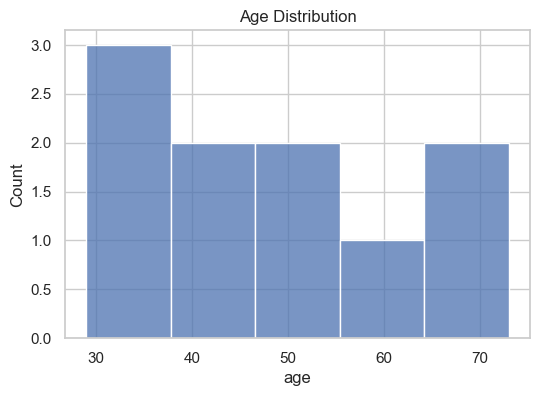

In [125]:
# Histogram: distribution of age
plt.figure(figsize=(6,4))
sns.histplot(df["age"])
plt.title("Age Distribution")
plt.show()

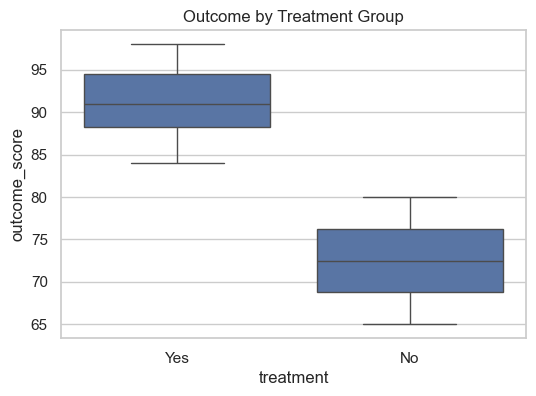

In [126]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x="treatment", y="outcome_score", data=df)
plt.title("Outcome by Treatment Group")
plt.show()

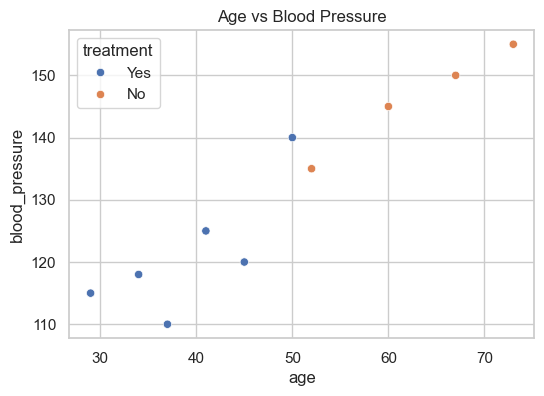

In [127]:
# Scatterplot
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="blood_pressure", hue="treatment", data=df)
plt.title("Age vs Blood Pressure")
plt.show()

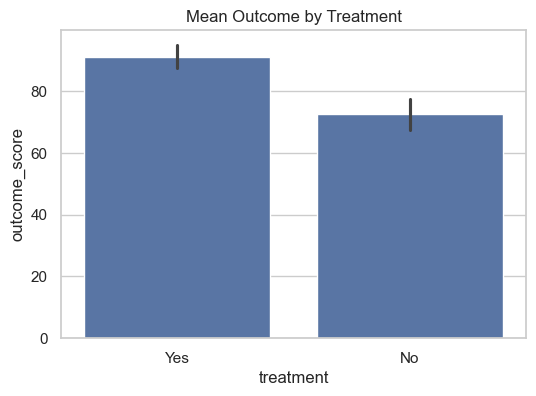

In [128]:
# Barplot
plt.figure(figsize=(6,4))
sns.barplot(x="treatment", y="outcome_score", data=df, estimator=np.mean)
plt.title("Mean Outcome by Treatment")
plt.show()

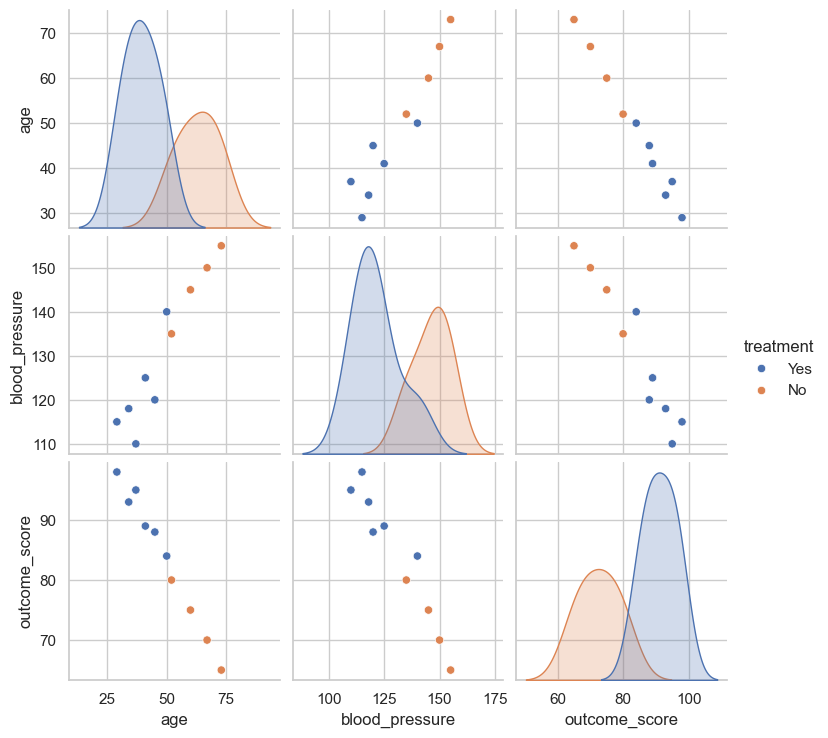

In [131]:
# All pairwise variable relationships
sns.pairplot(df, hue="treatment")
plt.show()